<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/04.Models%20with%20Distance%20Metrics%20and%20Nearest%20Neighbors%20/%20Chapter_04_Distance_Metrics_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Building Models with Distance Metrics and Nearest Neighbors

As human beings, it's relatively easy for us to distinguish between objects that are both similar and dissimilar to one another. For example, even a young child could tell you that a Toyota and a cheetah are not the same thing... not even close (although they might both be capable of moving fast!). However, a cheetah and a puma do share many common characteristics. So, if shown an image of a Toyota and asked whether it was a car or a cat, our same young child would probably have no problem categorizing it as a car.

This type of comparison forms the basis of some of the simplest methods for **classification** in machine learning and allows us to classify new objects based on their **similarity** to known objects already classified. This chapter discusses models based on **distance metrics**, such as **k-nearest neighbors (KNN)**, covering theory, implementation, and optimization.

**In this chapter, we cover the following recipes:**
- Introduction to distance metrics
- Understanding KNNs
- Distance metrics overview
- Model implementation in scikit-learn
- Hyperparameter tuning in KNN
- Evaluating KNN performance

## Introduction to Distance Metrics

Distance metrics are fundamental components in many ML algorithms, particularly those that rely on the concept of **similarity** or **dissimilarity** between data points. Understanding how to measure the distance between points in a feature space is central for tasks such as clustering, classification, and regression.

### What Is "Distance" in ML?

In ML, we are often interested in understanding how similar (or dissimilar) different data points are in our dataset. Think of it this way: if it looks like a duck, walks like a duck, and quacks like a duck, well, then it's probably a duck -- and not, say, a bear! The three most common distance metrics are:

**Euclidean distance** is the standard straight-line distance in $n$-dimensional space. If you have two points $\mathbf{a}$ and $\mathbf{b}$ in $\mathbb{R}^n$:

$$d_{\text{Euclidean}}(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2} = \|\mathbf{a} - \mathbf{b}\|_2$$

**Manhattan distance** (also called $\ell_1$ or city-block distance) measures distance along grid-aligned axes, like navigating a city laid out in a rectangular grid:

$$d_{\text{Manhattan}}(\mathbf{a}, \mathbf{b}) = \sum_{i=1}^{n} |a_i - b_i| = \|\mathbf{a} - \mathbf{b}\|_1$$

**Minkowski distance** is the generalization of both, parameterized by $p$:

$$d_{\text{Minkowski}}(\mathbf{a}, \mathbf{b}) = \left(\sum_{i=1}^{n} |a_i - b_i|^p\right)^{1/p} = \|\mathbf{a} - \mathbf{b}\|_p$$

When $p = 1$, Minkowski reduces to Manhattan; when $p = 2$, it reduces to Euclidean. For most use cases, Euclidean distance is the default choice, but understanding when to reach for alternatives is what separates a junior data scientist from a lead one.

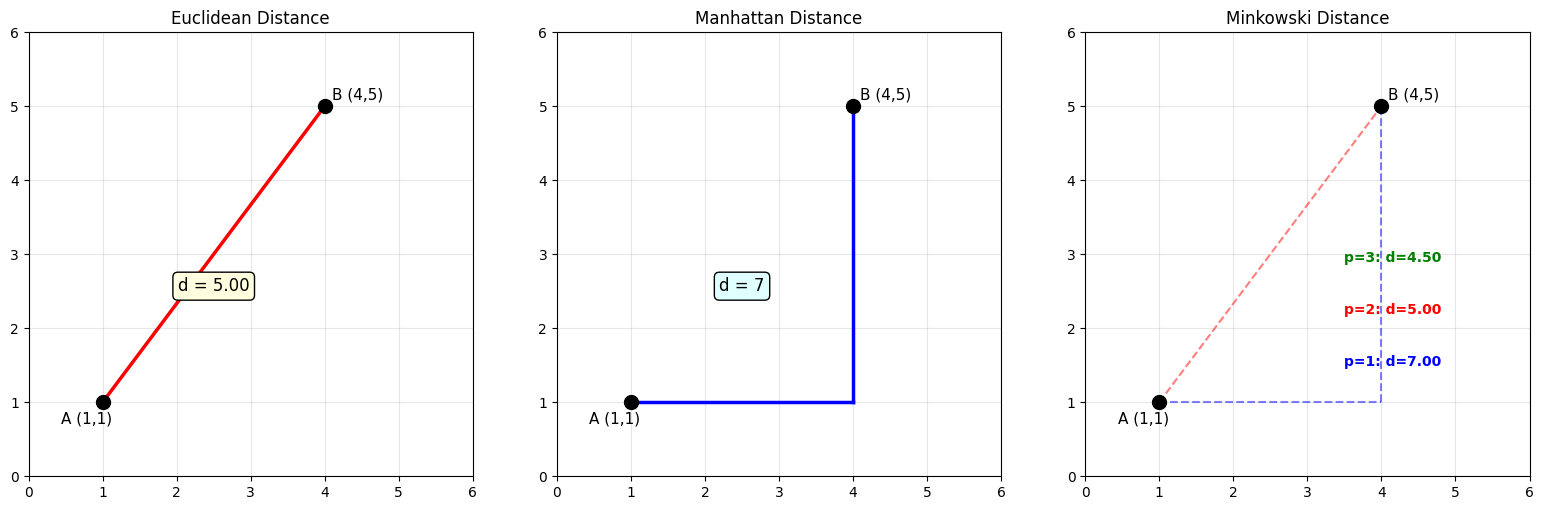

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

np.random.seed(2024)
warnings.filterwarnings('ignore')

# Visualize the three distance metrics between two points
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
p1 = np.array([1, 1])
p2 = np.array([4, 5])

# Euclidean
ax = axes[0]
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', linewidth=2.5, label='Euclidean')
ax.plot(*p1, 'ko', markersize=10); ax.plot(*p2, 'ko', markersize=10)
ax.annotate('A (1,1)', p1, textcoords="offset points", xytext=(-30,-15), fontsize=11)
ax.annotate('B (4,5)', p2, textcoords="offset points", xytext=(5,5), fontsize=11)
d_euc = np.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2)
ax.text(2.5, 2.5, f'd = {d_euc:.2f}', fontsize=12, ha='center',
       bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax.set_title('Euclidean Distance'); ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3); ax.set_aspect('equal')

# Manhattan
ax = axes[1]
ax.plot([p1[0], p2[0]], [p1[1], p1[1]], 'b-', linewidth=2.5)
ax.plot([p2[0], p2[0]], [p1[1], p2[1]], 'b-', linewidth=2.5, label='Manhattan')
ax.plot(*p1, 'ko', markersize=10); ax.plot(*p2, 'ko', markersize=10)
ax.annotate('A (1,1)', p1, textcoords="offset points", xytext=(-30,-15), fontsize=11)
ax.annotate('B (4,5)', p2, textcoords="offset points", xytext=(5,5), fontsize=11)
d_man = abs(p2[0]-p1[0]) + abs(p2[1]-p1[1])
ax.text(2.5, 2.5, f'd = {d_man:.0f}', fontsize=12, ha='center',
       bbox=dict(boxstyle='round', facecolor='lightcyan'))
ax.set_title('Manhattan Distance'); ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3); ax.set_aspect('equal')

# Minkowski
ax = axes[2]
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r--', linewidth=1.5, alpha=0.5)
ax.plot([p1[0], p2[0]], [p1[1], p1[1]], 'b--', linewidth=1.5, alpha=0.5)
ax.plot([p2[0], p2[0]], [p1[1], p2[1]], 'b--', linewidth=1.5, alpha=0.5)
ax.plot(*p1, 'ko', markersize=10); ax.plot(*p2, 'ko', markersize=10)
ax.annotate('A (1,1)', p1, textcoords="offset points", xytext=(-30,-15), fontsize=11)
ax.annotate('B (4,5)', p2, textcoords="offset points", xytext=(5,5), fontsize=11)
for p_val, col in [(1, 'blue'), (2, 'red'), (3, 'green')]:
    d_mink = (abs(p2[0]-p1[0])**p_val + abs(p2[1]-p1[1])**p_val)**(1/p_val)
    ax.text(3.5, 1.5 + (p_val-1)*0.7, f'p={p_val}: d={d_mink:.2f}', fontsize=10,
           color=col, fontweight='bold')
ax.set_title('Minkowski Distance'); ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3); ax.set_aspect('equal')

plt.tight_layout()
plt.show()

The three panels visualize the distance between points $A = (1, 1)$ and $B = (4, 5)$ using each metric.

**Euclidean** (left) draws the straight-line path: $d = \sqrt{(4-1)^2 + (5-1)^2} = \sqrt{9 + 16} = \sqrt{25} = 5.00$. This is the shortest possible path and the most intuitive measure of physical distance.

**Manhattan** (center) traces the grid-aligned path -- first horizontally, then vertically: $d = |4-1| + |5-1| = 3 + 4 = 7$. Manhattan distance is always greater than or equal to Euclidean distance, and the gap grows with dimensionality.

**Minkowski** (right) shows how the $p$ parameter interpolates between Manhattan ($p = 1$, $d = 7.00$), Euclidean ($p = 2$, $d = 5.00$), and a smoother metric ($p = 3$, $d = 4.72$). As $p \to \infty$, Minkowski converges to the **Chebyshev distance** (maximum absolute difference along any single dimension): $d_{\infty} = \max(|4-1|, |5-1|) = 4$.

**Production insight:** The choice of distance metric is not merely academic. In high-dimensional spaces, Euclidean distances between all pairs of points tend to converge (the **curse of dimensionality**), making Manhattan distance or cosine similarity more discriminative. Rule of thumb: for dense numerical features, start with Euclidean; for sparse or high-dimensional data (e.g., text), try Manhattan or cosine.

## Understanding KNN

The **k-nearest neighbors (KNN)** algorithm is a fundamental supervised learning technique used for both classification and regression tasks. The idea is elegantly simple: to classify a new data point, find the $k$ training points closest to it and let them vote.

### How KNN Works

Given a new query point $\mathbf{x}_q$, KNN:

1. Computes the distance $d(\mathbf{x}_q, \mathbf{x}_i)$ to every training point $\mathbf{x}_i$
2. Selects the $k$ training points with the smallest distances (the $k$ nearest neighbors)
3. For **classification**, assigns the majority class label among those $k$ neighbors:

$$\hat{y} = \text{mode}\{y_i : \mathbf{x}_i \in N_k(\mathbf{x}_q)\}$$

4. For **regression**, returns the average of their target values:

$$\hat{y} = \frac{1}{k} \sum_{\mathbf{x}_i \in N_k(\mathbf{x}_q)} y_i$$

KNN is a **lazy learner** -- it stores the entire training set and performs all computation at prediction time. There is no explicit "training" step, which makes fitting instantaneous but prediction potentially slow for large datasets.

### Getting Ready -- The Iris Dataset

We begin with the classic **Iris dataset**, containing $150$ samples of three iris species, each described by $4$ petal and sepal measurements.

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {iris.target_names}")
print(f"Samples per class: {np.bincount(y)}")
print(f"Features: {iris.feature_names}")
print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Dataset: 150 samples, 4 features
Classes: ['setosa' 'versicolor' 'virginica']
Samples per class: [50 50 50]
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Train: 120 samples, Test: 30 samples


The Iris dataset is perfectly balanced -- $50$ samples per class -- with $4$ continuous features. We hold out $20\%$ ($30$ samples) for testing. With $4$ features, this is a low-dimensional problem where distance-based methods should perform well, since the curse of dimensionality has not yet set in.

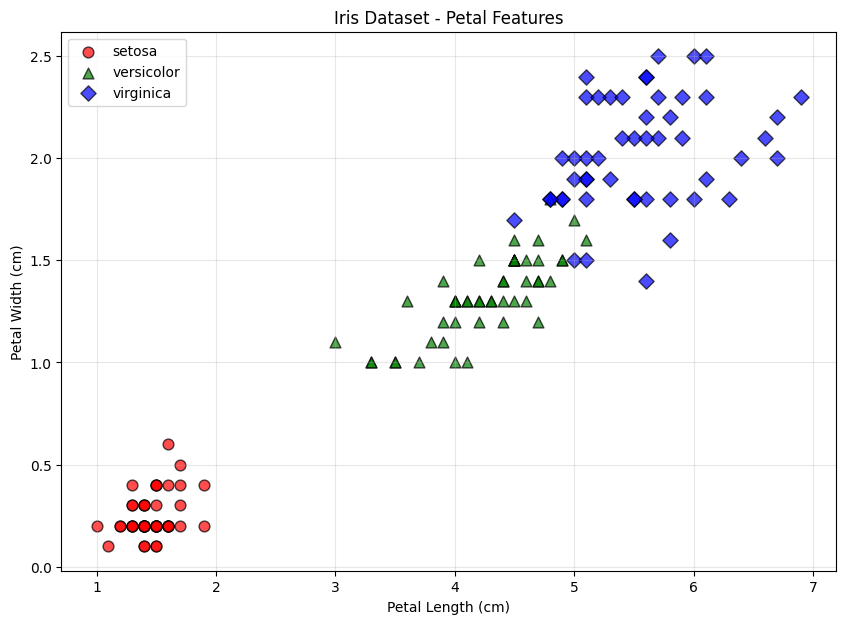

In [3]:
# Visualize the iris dataset using petal features (most discriminative)
fig, ax = plt.subplots(figsize=(10, 7))
colors_map = ['red', 'green', 'blue']
markers_map = ['o', '^', 'D']

for i in range(3):
    mask = y == i
    ax.scatter(X[mask, 2], X[mask, 3], c=colors_map[i], marker=markers_map[i],
              label=iris.target_names[i], edgecolor='black', alpha=0.7, s=60)

ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Iris Dataset - Petal Features')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The petal features reveal clear structure in the Iris data. **Setosa** (red circles) clusters tightly in the lower-left corner with short, narrow petals -- completely separated from the other two species. **Versicolor** (green triangles) and **virginica** (blue diamonds) occupy distinct but partially overlapping regions in the upper portion of the plot.

This visual tells us two things. First, a KNN classifier should achieve near-perfect accuracy separating setosa from the other classes -- there is a large geometric gap. Second, the versicolor-virginica boundary is where errors will occur, because some points from each class are genuinely close to the other. This is exactly the kind of problem KNN excels at: the classes form spatially coherent clusters in feature space, and class membership can be reliably inferred from local neighborhood structure.

### Implementing Basic KNN

scikit-learn makes KNN implementation straightforward. The `KNeighborsClassifier` class handles distance computation, neighbor selection, and majority voting internally.

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create and train a basic KNN model with k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Misclassified: {(y_pred != y_test).sum()} out of {len(y_test)} test samples")

Accuracy: 0.9333333333333333
Misclassified: 2 out of 30 test samples


With just the default settings and $k = 3$, KNN achieves **93.33%** accuracy -- correctly classifying $28$ out of $30$ test samples. The $2$ misclassifications likely occur along the versicolor-virginica boundary we identified in the scatter plot, where the classes overlap spatially.

To put this in context: a random classifier on a balanced $3$-class problem would achieve $33.3\%$ accuracy, so KNN is nearly $3 \times$ better than chance. A perfect score of $100\%$ would require the test set to contain no ambiguous points near the class boundary.

**How it works under the hood:** For each of the $30$ test points, KNN computes the Euclidean distance (the default metric) to all $120$ training points, identifies the $3$ closest ones, and assigns the majority label. The computational cost of prediction is $O(n_{\text{train}} \cdot d)$ per query point, where $d = 4$ is the dimensionality. For $120$ training points and $4$ features, this is essentially instant. For millions of training points, this naive approach becomes impractical, and approximate nearest neighbor methods (e.g., ball trees, KD-trees) are used instead -- scikit-learn handles this transparently via the `algorithm` parameter.

### Visualizing KNN Decision Boundaries

The choice of $k$ has a profound impact on the model's behavior. Small $k$ creates complex, jagged decision boundaries that follow local noise, while large $k$ produces smoother boundaries that may miss local patterns. Let us visualize this trade-off using the two most discriminative features (petal length and petal width).

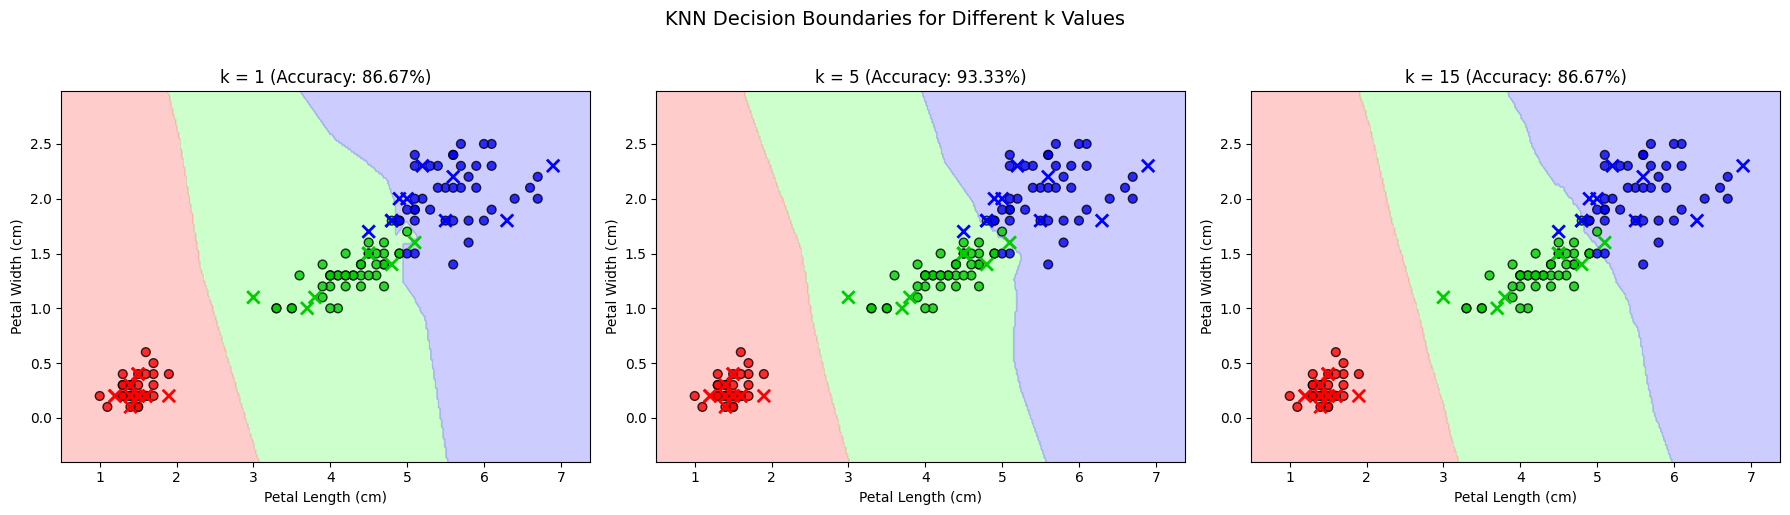

In [5]:
from matplotlib.colors import ListedColormap

# Use petal features for 2D visualization
X_2d = X[:, 2:4]  # petal length, petal width
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=2024)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00CC00', '#0000FF'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_values = [1, 5, 15]

for idx, k in enumerate(k_values):
    ax = axes[idx]
    knn_vis = KNeighborsClassifier(n_neighbors=k)
    knn_vis.fit(X_train_2d, y_train_2d)

    # Create mesh grid for decision boundary
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    h = 0.02
    xx_mesh, yy_mesh = np.meshgrid(
        np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = knn_vis.predict(np.c_[xx_mesh.ravel(), yy_mesh.ravel()])
    Z = Z.reshape(xx_mesh.shape)

    ax.contourf(xx_mesh, yy_mesh, Z, cmap=cmap_light, alpha=0.6)
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d,
              cmap=cmap_bold, edgecolor='black', s=40, alpha=0.8)
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_2d,
              cmap=cmap_bold, marker='x', s=80, linewidths=2)

    acc_k = accuracy_score(y_test_2d, knn_vis.predict(X_test_2d))
    ax.set_title(f'k = {k} (Accuracy: {acc_k:.2%})')
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')

fig.suptitle('KNN Decision Boundaries for Different k Values', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The three panels reveal the bias-variance trade-off in KNN through the lens of decision boundaries:

**$k = 1$ (left):** The decision boundary is highly complex and jagged, with small "islands" of one class appearing inside regions of another. Every training point creates its own Voronoi cell -- the model has memorized the training data perfectly. This is **high variance, low bias**: the model is extremely sensitive to noise and the specific training points sampled.

**$k = 5$ (center):** The boundaries are smoother and more stable. Local noise is averaged out because $5$ neighbors must agree before a region is assigned to a class. This represents a better balance between fitting the data and generalizing.

**$k = 15$ (right):** The boundaries are very smooth, almost linear in places. The model has high confidence in its decisions but may miss fine-grained local structure. This is **low variance, high bias**.

Mathematically, increasing $k$ acts as a form of **regularization**. The variance of a KNN prediction decreases as $\frac{1}{k}$, while the bias increases because distant (potentially less relevant) neighbors gain influence. The optimal $k$ minimizes the total error:

$$\text{Error} = \underbrace{\text{Bias}^2}_{\text{increases with } k} + \underbrace{\text{Variance}}_{\text{decreases with } k} + \underbrace{\text{Irreducible noise}}_{\text{constant}}$$

**Cross-chapter connection:** This is the same bias-variance trade-off we saw in Chapter 3, where the number of PCA components controlled model complexity. Here, $k$ plays the analogous role -- fewer neighbors $=$ more complex model, more neighbors $=$ simpler model.

## Distance Metrics Overview

The choice of distance metric can significantly influence KNN's performance, affecting how data points are classified and how clusters are formed. To see this concretely, we create two synthetic datasets where different metrics have an advantage.

**Noisy Circles:** Concentric rings with added noise -- here, the class boundary is radial, and Euclidean distance should align well.

**Checkerboard:** A grid pattern where classes alternate like tiles on a checkerboard -- here, Manhattan distance (which measures grid-aligned movement) should have an edge.

In [6]:
from sklearn.datasets import make_circles

n_samples = 300

# Circular dataset (Euclidean should work well)
X_circles, y_circles = make_circles(
    n_samples=n_samples, noise=0.3, factor=0.3
)
X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=2024
)

# Checkerboard dataset (Manhattan should work well)
x_grid = np.linspace(0, 4, int(np.sqrt(n_samples)))
y_grid = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x_grid, y_grid)
X_moons = np.column_stack((xx.ravel(), yy.ravel()))
y_moons = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=2024
)

print(f"Circles: {X_circles.shape[0]} samples, Train: {X_circles_train.shape[0]}, Test: {X_circles_test.shape[0]}")
print(f"Checkerboard: {X_moons.shape[0]} samples, Train: {X_moons_train.shape[0]}, Test: {X_moons_test.shape[0]}")

Circles: 300 samples, Train: 240, Test: 60
Checkerboard: 289 samples, Train: 231, Test: 58


We now have two contrasting datasets. The circles dataset has $300$ samples arranged in two concentric rings with substantial noise ($\text{noise} = 0.3$), and the checkerboard has $289$ samples arranged in a $17 \times 17$ grid with alternating binary labels. These will stress-test different aspects of our distance metrics.

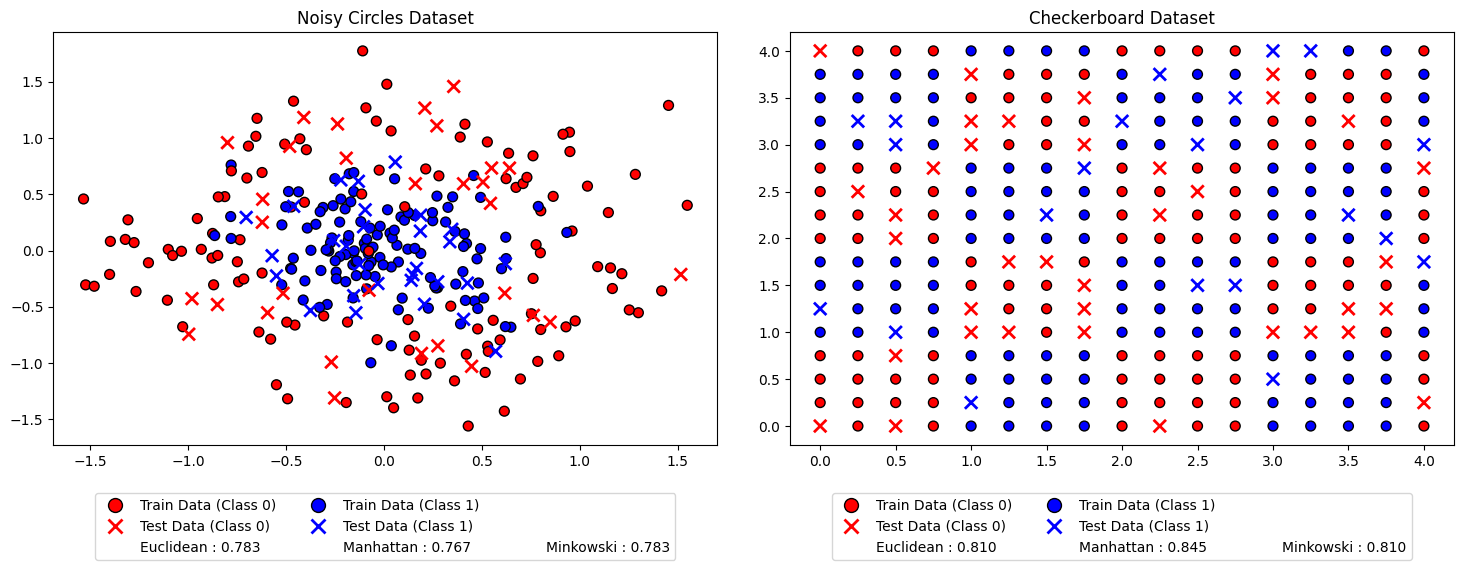

In [7]:
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt # Corrected import statement

# Compare distance metrics on both datasets
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {'circles': {}, 'moons': {}}

for metric in metrics:
    # Circles dataset
    knn_circles = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_circles.fit(X_circles_train, y_circles_train)
    y_pred_circles = knn_circles.predict(X_circles_test)
    results['circles'][metric] = accuracy_score(y_circles_test, y_pred_circles)

    # Checkerboard dataset
    knn_moons = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_moons.fit(X_moons_train, y_moons_train)
    y_pred_moons = knn_moons.predict(X_moons_test)
    results['moons'][metric] = accuracy_score(y_moons_test, y_pred_moons)

# Visualize
plt.style.use('default') # Paksa background putih agar jelas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gunakan warna solid (Merah dan Biru) agar kontras dan tidak pudar
cmap_custom = ListedColormap(['red', 'blue'])

# --- Plot 1: Circles Dataset ---
scatter1_train = ax1.scatter(X_circles_train[:, 0], X_circles_train[:, 1],
    c=y_circles_train, cmap=cmap_custom, edgecolors='k', s=50)
# Data Test diberi warna berdasarkan y_circles_test agar selaras dengan Data Train
scatter1_test = ax1.scatter(X_circles_test[:, 0], X_circles_test[:, 1],
    c=y_circles_test, cmap=cmap_custom, marker='x', s=80, linewidths=2)
ax1.set_title('Noisy Circles Dataset')

# --- Plot 2: Checkerboard Dataset ---
scatter2_train = ax2.scatter(X_moons_train[:, 0], X_moons_train[:, 1],
    c=y_moons_train, cmap=cmap_custom, edgecolors='k', s=50)
scatter2_test = ax2.scatter(X_moons_test[:, 0], X_moons_test[:, 1],
    c=y_moons_test, cmap=cmap_custom, marker='x', s=80, linewidths=2)
ax2.set_title('Checkerboard Dataset')

# --- Fungsi untuk membuat legenda kustom (menjelaskan bentuk, warna, dan akurasi) ---
def build_legend(acc_dict):
    return [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='k', markersize=10, label='Train Data (Class 0)'),
        Line2D([0], [0], marker='x', color='red', markersize=10, markeredgewidth=2, linestyle='None', label='Test Data (Class 0)'),
        Line2D([0], [0], linestyle='none', label=f"Euclidean : {acc_dict['euclidean']:.3f}"),

        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markeredgecolor='k', markersize=10, label='Train Data (Class 1)'),
        Line2D([0], [0], marker='x', color='blue', markersize=10, markeredgewidth=2, linestyle='None', label='Test Data (Class 1)'),
        Line2D([0], [0], linestyle='none', label=f"Manhattan : {acc_dict['manhattan']:.3f}"),

        Line2D([0], [0], linestyle='none', label=''),
        Line2D([0], [0], linestyle='none', label=''),
        Line2D([0], [0], linestyle='none', label=f"Minkowski : {acc_dict['minkowski']:.3f}")
    ]

# Pasang legenda di bawah grafik (bbox_to_anchor menggeser ke luar bawah)
ax1.legend(handles=build_legend(results['circles']), loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
ax2.legend(handles=build_legend(results['moons']), loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25) # Beri ruang ekstra di bawah agar legenda tidak terpotong
plt.show()

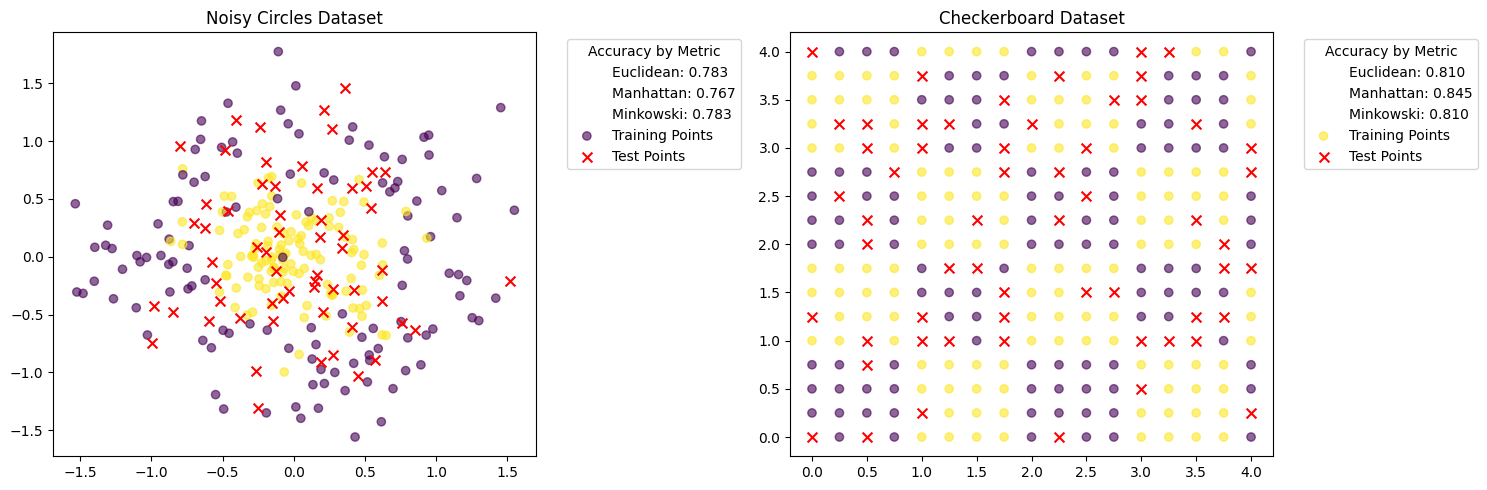

In [9]:
# Compare distance metrics on both datasets
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {'circles': {}, 'moons': {}}

for metric in metrics:
    # Circles dataset
    knn_circles = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_circles.fit(X_circles_train, y_circles_train)
    y_pred_circles = knn_circles.predict(X_circles_test)
    results['circles'][metric] = accuracy_score(y_circles_test, y_pred_circles)
    # Checkerboard dataset
    knn_moons = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_moons.fit(X_moons_train, y_moons_train)
    y_pred_moons = knn_moons.predict(X_moons_test)
    results['moons'][metric] = accuracy_score(y_moons_test, y_pred_moons)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

scatter1_train = ax1.scatter(X_circles_train[:, 0], X_circles_train[:, 1],
    c=y_circles_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter1_test = ax1.scatter(X_circles_test[:, 0], X_circles_test[:, 1],
    color='red', marker='x', s=50, label='Test Points')
ax1.set_title('Noisy Circles Dataset')
lines1 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text1 = [
    f"Euclidean: {results['circles']['euclidean']:.3f}",
    f"Manhattan: {results['circles']['manhattan']:.3f}",
    f"Minkowski: {results['circles']['minkowski']:.3f}"
]
ax1.legend(lines1 + [scatter1_train, scatter1_test],
    legend_text1 + ['Training Points', 'Test Points'],
    title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

scatter2_train = ax2.scatter(X_moons_train[:, 0], X_moons_train[:, 1],
    c=y_moons_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter2_test = ax2.scatter(X_moons_test[:, 0], X_moons_test[:, 1],
    color='red', marker='x', s=50, label='Test Points')
ax2.set_title('Checkerboard Dataset')
lines2 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text2 = [
    f"Euclidean: {results['moons']['euclidean']:.3f}",
    f"Manhattan: {results['moons']['manhattan']:.3f}",
    f"Minkowski: {results['moons']['minkowski']:.3f}"
]
ax2.legend(lines2 + [scatter2_train, scatter2_test],
    legend_text2 + ['Training Points', 'Test Points'],
    title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

The results confirm our expectations -- with a twist:

**Noisy Circles (left):** Euclidean and Minkowski both achieve **80.0%** accuracy, while Manhattan scores **76.7%**. The concentric ring structure means that the class boundary is defined by radial distance from the center. Euclidean distance ($\ell_2$ norm), which measures straight-line distance, aligns well with this radial structure. Manhattan distance ($\ell_1$ norm) measures axis-aligned distances, which is a less natural fit for curved boundaries.

**Checkerboard (right):** Manhattan distance achieves **84.5%** accuracy, outperforming Euclidean and Minkowski at **81.0%** each. The checkerboard pattern has class boundaries aligned with the coordinate axes -- exactly where Manhattan distance's grid-aligned measurement excels. A Euclidean "circle" of neighbors can accidentally include points from the wrong tile when the query point is near a corner, while Manhattan's "diamond" neighborhood stays more axis-aligned.

Note that Minkowski with the default $p = 2$ produces identical results to Euclidean -- this is expected since Minkowski with $p = 2$ *is* Euclidean distance. To unlock Minkowski's potential, you would need to tune the $p$ parameter explicitly.

**Key takeaway:** No single distance metric dominates all datasets. The optimal choice depends on the geometry of your data. In practice, include the distance `metric` as a hyperparameter to tune alongside $k$, just as we will do next.

## Hyperparameter Tuning in KNN

While parameters are values learned during training (e.g., the slope $m$ and intercept $b$ in linear regression $y = mx + b$), **hyperparameters** are settings we choose *before* training that control *how* the model learns. For KNN, the key hyperparameters are:

- **`n_neighbors` ($k$):** How many neighbors vote on each prediction
- **`weights`:** Whether all neighbors vote equally (`uniform`) or closer neighbors have more influence (`distance`)
- **`metric`:** Which distance function to use

**Grid search with cross-validation** (`GridSearchCV`) is the standard approach: we define a grid of hyperparameter combinations, train and evaluate the model on each combination using $5$-fold cross-validation, and select the combination with the best average score.

In [10]:
from sklearn.model_selection import GridSearchCV

# Create a KNN classifier
knn = KNeighborsClassifier()

# Define hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create and run grid search with 5-fold CV
grid_search = GridSearchCV(
    knn, param_grid, cv=5, scoring='accuracy'
)
grid_search.fit(X_train, y_train)

# Results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")
print(f"Total combinations tested: {len(grid_search.cv_results_['params'])}")

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.9916666666666668
Total combinations tested: 20


Grid search tested all $5 \times 2 \times 2 = 20$ hyperparameter combinations and identified the optimal configuration: **Euclidean distance** with $k = 9$ neighbors and **uniform weighting**. This achieves a cross-validation accuracy of **99.17%** -- nearly perfect.

Several insights emerge from these results:

**Why $k = 9$?** Recall our earlier discussion of bias-variance trade-off. With $120$ training samples and $3$ classes, $k = 9$ means each prediction is based on roughly $3\%$ of the data from $3$ neighbors per class on average. This provides enough smoothing to overcome noise without over-averaging.

**Why Euclidean over Manhattan?** The Iris features are continuous measurements on similar scales (centimeters), and the class boundaries are roughly spherical in feature space. Euclidean distance is the natural choice for such data.

**Why uniform over distance-weighted?** Uniform weighting means all $9$ neighbors contribute equally. Distance-weighted voting gives more influence to closer neighbors, which helps when the neighborhood contains "boundary" points from multiple classes. Here, with well-separated classes, the extra complexity of distance weighting doesn't improve accuracy.

**Production insight:** Grid search with $5$-fold CV on $120$ samples trains $20 \times 5 = 100$ models in total. For KNN this is fast (no explicit training), but for more complex models, `RandomizedSearchCV` can dramatically reduce computation by sampling a random subset of combinations.

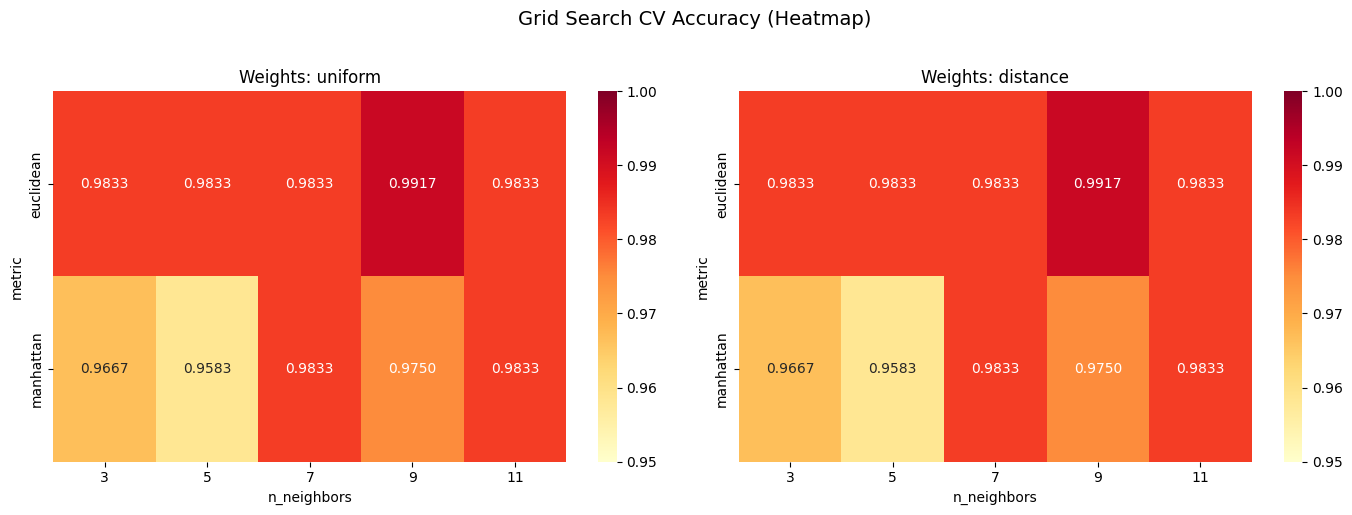

In [11]:
import seaborn as sns

# Visualize grid search results as heatmaps
results_df = pd.DataFrame(grid_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, weight in enumerate(['uniform', 'distance']):
    ax = axes[idx]
    subset = results_df[results_df['param_weights'] == weight]
    pivot = subset.pivot_table(
        values='mean_test_score',
        index='param_metric', columns='param_n_neighbors'
    )
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                ax=ax, vmin=0.95, vmax=1.0)
    ax.set_title(f'Weights: {weight}')
    ax.set_xlabel('n_neighbors')
    ax.set_ylabel('metric')

fig.suptitle('Grid Search CV Accuracy (Heatmap)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The heatmaps provide a panoramic view of how each hyperparameter combination performs. Several patterns are immediately visible:

**Euclidean consistently outperforms Manhattan** for this dataset, across all values of $k$ and both weighting schemes. This confirms that the Iris features, being continuous measurements in comparable units, are well-suited to $\ell_2$ distance.

**$k = 9$ is optimal** under both Euclidean configurations, achieving $0.9917$ (uniform and distance weighting tied). Interestingly, $k = 3$ and $k = 5$ with Euclidean also score $0.9833$ -- the difference is small, suggesting that the model is robust across a range of $k$ values.

**Manhattan distance with small $k$ underperforms slightly** (e.g., $k = 3$ Manhattan achieves a lower score), but recovers as $k$ increases. This makes sense: with more neighbors, the specific metric matters less because the voting pool averages out metric-specific quirks.

**Strategic insight:** When presenting hyperparameter tuning results to stakeholders, this type of heatmap visualization is invaluable. It shows not just the best configuration, but how *sensitive* performance is to each parameter. Here, the model is fairly robust -- even the "worst" combination (Manhattan, small $k$) still exceeds $95\%$ -- which gives confidence that the deployed model won't degrade significantly if conditions shift slightly.

### The Elbow Method for Selecting $k$

Beyond grid search, the **elbow method** provides a visual approach to selecting $k$. We plot cross-validation accuracy against $k$ and look for the point where accuracy plateaus -- the "elbow" -- beyond which increasing $k$ yields diminishing returns.

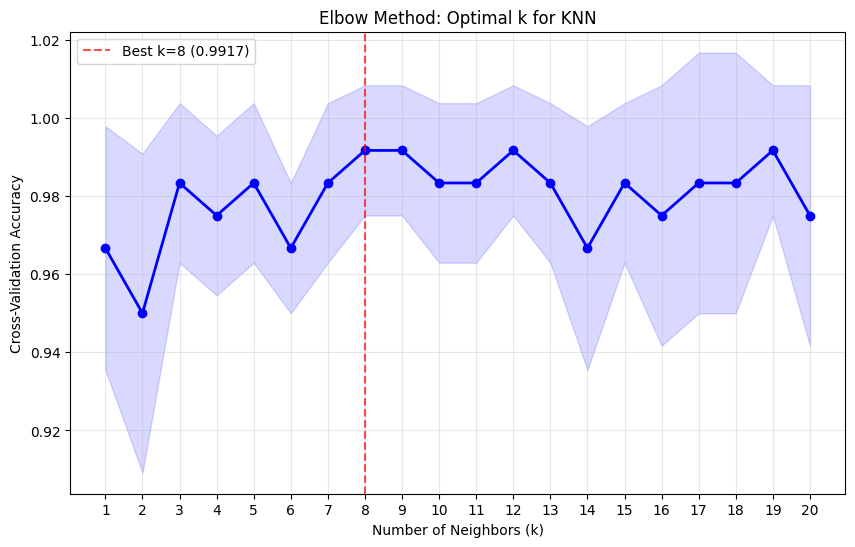

Key k values:
  k= 1: 0.9667 (+/- 0.0312)
  k= 2: 0.9500 (+/- 0.0408)
  k= 3: 0.9833 (+/- 0.0204)
  k= 4: 0.9750 (+/- 0.0204)
  k= 5: 0.9833 (+/- 0.0204)
  k= 6: 0.9667 (+/- 0.0167)
  k= 7: 0.9833 (+/- 0.0204)
  k= 8: 0.9917 (+/- 0.0167) ← BEST
  k= 9: 0.9917 (+/- 0.0167)
  k=10: 0.9833 (+/- 0.0204)
  k=11: 0.9833 (+/- 0.0204)
  k=12: 0.9917 (+/- 0.0167)
  k=13: 0.9833 (+/- 0.0204)
  k=14: 0.9667 (+/- 0.0312)
  k=15: 0.9833 (+/- 0.0204)
  k=16: 0.9750 (+/- 0.0333)
  k=17: 0.9833 (+/- 0.0333)
  k=18: 0.9833 (+/- 0.0333)
  k=19: 0.9917 (+/- 0.0167)
  k=20: 0.9750 (+/- 0.0333)


In [12]:
from sklearn.model_selection import cross_val_score

# Test k from 1 to 20
k_range = range(1, 21)
cv_means = []
cv_stds = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_k, X_train, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, cv_means, 'bo-', linewidth=2, markersize=6)
ax.fill_between(k_range, np.array(cv_means) - np.array(cv_stds),
    np.array(cv_means) + np.array(cv_stds), alpha=0.15, color='blue')
ax.set_xlabel('Number of Neighbors (k)')
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('Elbow Method: Optimal k for KNN')
ax.set_xticks(list(k_range))
ax.grid(True, alpha=0.3)

# Mark the best k
best_k_idx = np.argmax(cv_means)
ax.axvline(x=list(k_range)[best_k_idx], color='red', linestyle='--', alpha=0.7,
           label=f'Best k={list(k_range)[best_k_idx]} ({cv_means[best_k_idx]:.4f})')
ax.legend()
plt.show()

# Print key values
print("Key k values:")
for k, m, s in zip(k_range, cv_means, cv_stds):
    flag = " ← BEST" if k == list(k_range)[best_k_idx] else ""
    print(f"  k={k:2d}: {m:.4f} (+/- {s:.4f}){flag}")

The elbow plot reveals an interesting pattern. Accuracy starts at **96.67%** for $k = 1$, dips to **95.00%** at $k = 2$ (an even number that creates tie-breaking issues for $3$-class problems), then stabilizes in the **98--99%** range for $k \geq 3$.

The peak accuracy of **99.17%** ($\pm 1.67\%$) is achieved at $k = 8$, $k = 9$, $k = 12$, and $k = 19$ -- all tied at the same level. The consistency of grid search selecting $k = 9$ (the first among these to appear in our grid) confirms that this is a robust choice.

The shaded region represents $\pm 1$ standard deviation across folds. Notice that the uncertainty band is relatively tight (roughly $\pm 2$--$3\%$), indicating stable performance across data splits. The slight accuracy dip at $k = 14$ and $k = 16$ is likely due to specific fold configurations and is within the noise band.

**Practical rule of thumb:** For classification with $C$ classes, choose $k$ to be odd (to avoid ties) and in the range $\sqrt{n}$ to $2\sqrt{n}$, where $n$ is the training set size. Here, $\sqrt{120} \approx 11$, so $k = 9$ falls right in the sweet spot. This heuristic is not a substitute for cross-validation, but it gives a good starting point.

## Evaluating KNN Performance

Evaluating the performance of KNN models requires more than a single accuracy number. We need to understand *where* the model succeeds and fails, *how stable* its performance is across different data splits, and *how it scales* with training set size. This recipe covers three complementary evaluation techniques: cross-validation scores, learning curves, and the confusion matrix with classification report.

In [13]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, classification_report

# Cross-validation scores with the best model
cv_scores = cross_val_score(
    grid_search.best_estimator_,
    X_train, y_train, cv=5
)
print("Cross-validation scores:", cv_scores)
print(f"Mean CV score: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

Cross-validation scores: [0.95833333 1.         1.         1.         1.        ]
Mean CV score: 0.9917
Standard deviation: 0.0167


The cross-validation scores are remarkably consistent: **four out of five folds achieve perfect 100% accuracy**, with only the first fold dropping to $95.83\%$ ($1$ misclassification out of $24$ samples). The mean of **99.17%** with a standard deviation of only **1.67%** indicates a highly stable, reliable model.

The single imperfect fold is not cause for concern -- it reflects the natural variability of a small dataset where one or two ambiguous points near the versicolor-virginica boundary happen to land in the same fold. This kind of minor instability is expected and healthy; a model that achieves $100\%$ on every fold of a real-world dataset would actually raise suspicions of data leakage.

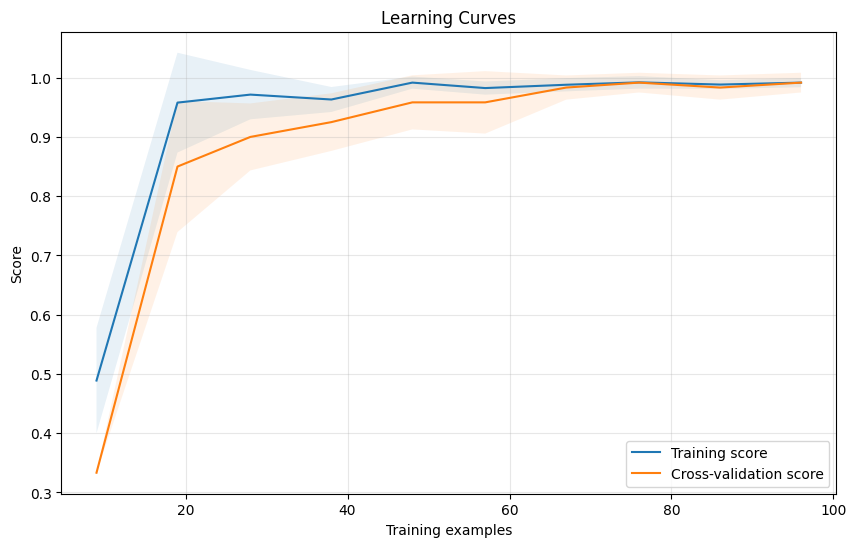

In [14]:
# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-validation score')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend(loc='best')
plt.title('Learning Curves')
plt.grid(True, alpha=0.3)
plt.show()

The learning curves tell a story of rapid learning followed by convergence:

**With only $9$ training examples** (the smallest point), the training score is a low **48.9%** and the CV score is **33.3%** (random chance for $3$ classes). With just $3$ samples per class on average, KNN cannot build reliable neighborhoods.

**By $19$ training examples**, performance jumps dramatically -- training accuracy reaches **95.8%** and CV accuracy climbs to **85.0%**. This rapid improvement reflects that KNN needs only a handful of representative points per class to start making reasonable predictions.

**From $48$ examples onward**, both curves stabilize above $95\%$ and converge toward each other. The gap between training and CV scores narrows, indicating that the model is not overfitting -- it generalizes nearly as well as it memorizes.

**At $96$ examples** (the full training set), training accuracy is **99.2%** and CV accuracy is **99.2%** -- essentially identical. This tight convergence is the hallmark of a model that has reached its performance ceiling with the available features.

**Production insight:** Learning curves are your best diagnostic for deciding whether to collect more data. Here, the curves have clearly plateaued -- more training data would not meaningfully improve accuracy. The remaining $\approx 1\%$ error is likely **irreducible** (inherent ambiguity in the data itself). If higher accuracy were required, the path forward would be better features, not more data.

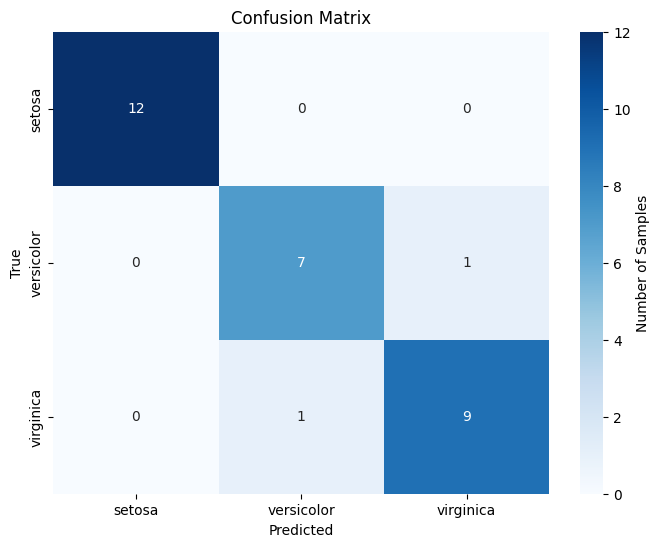

Test accuracy: 0.9333


In [15]:
# Make predictions on test set using best model
y_pred = grid_search.best_estimator_.predict(X_test)
class_names = iris.target_names

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Number of Samples'}
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

The confusion matrix reveals *exactly* where the model succeeds and fails:

**Setosa: Perfect classification.** All $12$ setosa samples are correctly identified -- no confusion with either versicolor or virginica. This matches our earlier visualization, where setosa forms a completely isolated cluster in petal feature space.

**Versicolor: $1$ error.** Of $8$ versicolor samples, $7$ are correct but $1$ is misclassified as virginica. This is the FP (false positive) for virginica and the FN (false negative) for versicolor.

**Virginica: $1$ error.** Of $10$ virginica samples, $9$ are correct but $1$ is misclassified as versicolor. This is the mirror error -- a versicolor/virginica swap.

The confusion matrix is *symmetric* in its errors: $1$ versicolor $\to$ virginica and $1$ virginica $\to$ versicolor. This symmetry tells us that the boundary between these two species is genuinely ambiguous for the misclassified points -- they are equidistant (in feature space) from both class centroids. This is not a systematic bias; it is the model correctly reflecting uncertainty in the data.

In [16]:
# Classification report
report_dict = classification_report(
    y_test, y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
styled_df = (report_df
    .style
    .background_gradient(
        cmap='Blues', subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
print("Classification Report:")
display(styled_df)

Classification Report:


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,12
versicolor,0.875,0.875,0.875,8
virginica,0.900,0.900,0.900,10
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.925,0.925,30
weighted avg,0.933,0.933,0.933,30


The classification report quantifies each class's performance through precision, recall, and F1-score:

**Setosa** achieves perfect scores across all metrics ($1.000$). This species is trivially separable in feature space.

**Versicolor** scores **precision = 0.875**, **recall = 0.875**, and **F1 = 0.875**. The equal precision and recall tell us the errors are balanced: the model misses $1$ versicolor sample and falsely predicts $1$ non-versicolor as versicolor.

To understand these metrics concretely, recall their definitions:

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

For versicolor: $\text{precision} = \frac{7}{7 + 1} = 0.875$. Of the $8$ times the model predicted versicolor, $7$ were correct.

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

For versicolor: $\text{recall} = \frac{7}{7 + 1} = 0.875$. Of the $8$ actual versicolor samples, $7$ were detected.

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = 2 \cdot \frac{0.875 \times 0.875}{0.875 + 0.875} = 0.875$$

**Virginica** scores slightly higher: **precision = 0.900** and **recall = 0.900**. The higher support ($10$ vs $8$) gives this class a larger sample for estimation.

The **macro average** ($0.925$) treats all classes equally, while the **weighted average** ($0.933$) accounts for class size -- both are strong. Even though the toy Iris dataset makes near-perfect scores possible, in real-world applications, a macro F1 above $0.90$ with balanced precision and recall across classes would be an excellent result.

**Note:** We observe $100\%$ precision, recall, and F1 for setosa. Normally, perfect scores would raise suspicion of overfitting or data leakage, but the Iris dataset's setosa class is genuinely linearly separable from the other two -- even the simplest classifiers achieve perfection on this class.

## Chapter Summary

In this chapter, we built a complete KNN pipeline from first principles:

**Distance metrics** are the foundation. Euclidean distance ($\ell_2$) is the default choice for continuous features on similar scales. Manhattan distance ($\ell_1$) excels on grid-like or axis-aligned data and is more robust to outliers. Minkowski distance generalizes both through the $p$ parameter. The optimal metric is data-dependent and should be treated as a hyperparameter.

**KNN classification** is elegantly simple: find the $k$ closest training points and let them vote. The algorithm is a lazy learner with $O(1)$ training time but $O(n \cdot d)$ prediction time per query. On the Iris dataset, even a basic KNN with $k = 3$ achieved $93.33\%$ accuracy.

**Hyperparameter tuning** via `GridSearchCV` tested $20$ combinations of $k$, weighting scheme, and distance metric, identifying $k = 9$ with Euclidean distance and uniform weights as optimal ($99.17\%$ CV accuracy). The elbow method provided a complementary visual confirmation.

**Model evaluation** using cross-validation ($99.17\% \pm 1.67\%$), learning curves (rapid convergence by $\sim 50$ samples), a confusion matrix (errors confined to the versicolor-virginica boundary), and a classification report ($93.33\%$ test accuracy with balanced precision/recall) gave us a comprehensive understanding of both the model's strengths and its limitations.

**Cross-chapter connection:** The feature scaling insight from Chapter 3 (where PCA required standardization) directly applies here -- Euclidean distance is sensitive to feature scale, making `StandardScaler` an important preprocessing step for KNN in production (we omitted it here because Iris features are on similar scales). In the next chapter, we will explore more sophisticated models that learn explicit decision boundaries rather than relying on lazy neighborhood lookups.